In [2]:
import ast
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
import lightgbm as lgb

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_squared_error as rmse
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", 100)

## Step 0 — Loading and Data Prep

In [3]:
# Load data
data_path = Path("data/visits.tsv")
visits = pd.read_csv(data_path, sep="\t")

print("Shape of original dataframe: ", visits.shape[0],'Rows x ',visits.shape[1], "Columns \n")
print("Data Type of each column in whole dataframe:\n")
original_data_types = visits.dtypes
print(original_data_types)

Shape of original dataframe:  40306 Rows x  7 Columns 

Data Type of each column in whole dataframe:

customer_id                       int64
viewed_products                     str
bought_products                     str
put_in_cart_products                str
num_of_times_search_was_used      int64
end                               int64
time_spent_in_minutes           float64
dtype: object


In [4]:
# Convert list-like string columns to list[int], then remove duplicates while preserving first-seen order

def process_product_columns(
        df: pd.DataFrame,
        columns: list[str],
        deduplicate_keep_order: bool=True,
        add_count: bool=True,
        count_suffix: str="total_",
) -> pd.DataFrame:

    # Parse list-columns, deduplicate (order-preserving) and add count columns

    out = df.copy()
    for col in columns:
        out[col] = out[col].apply(ast.literal_eval) # Convert string representation of list to actual list[int]
        if deduplicate_keep_order:
            out[col] = out[col].apply(lambda xs: list(dict.fromkeys(xs)))
        if add_count:
            out[f"{count_suffix}{col}"] = out[col].apply(len)
    return out

product_columns = ["viewed_products", "bought_products", "put_in_cart_products"]
visits = process_product_columns(visits, product_columns)

In [5]:
## Modify the datetime columns to add start datetime column as well as columns for hour, dow

# Convert end timestamp to datetime and extract features
visits["end_dt"] = pd.to_datetime(visits["end"], unit="ms", utc=False)
visits["end_dt"] = visits["end_dt"].dt.floor("10ms")
visits["end_hour"] = visits["end_dt"].dt.hour
visits["end_dayofweek"] = visits["end_dt"].dt.dayofweek + 1  # 1=Mon
visits["end_date"] = visits["end_dt"].dt.date

# Create start_dt from end_dt and time_spent_in_minutes, and extract features
visits["time_spent_in_minutes"] = pd.to_timedelta(visits["time_spent_in_minutes"], unit="m")

# Note: time_spent_in_minutes is a duration, so we convert it to timedelta before subtracting from end_dt to get start_dt
visits["start_dt"] = visits["end_dt"] - visits["time_spent_in_minutes"]
visits["start_dt"] = visits["start_dt"].dt.floor("10ms")
visits["start_hour"] = visits["start_dt"].dt.hour
visits["start_dayofweek"] = visits["start_dt"].dt.dayofweek + 1 # 1=Mon ... 7=Sun
visits["start_date"] = visits["start_dt"].dt.date

print("Data Type of each column in whole dataframe after data cleaning:\n")
updated_data_types = visits.dtypes
print(updated_data_types)

Data Type of each column in whole dataframe after data cleaning:

customer_id                               int64
viewed_products                          object
bought_products                          object
put_in_cart_products                     object
num_of_times_search_was_used              int64
end                                       int64
time_spent_in_minutes           timedelta64[ns]
total_viewed_products                     int64
total_bought_products                     int64
total_put_in_cart_products                int64
end_dt                           datetime64[ms]
end_hour                                  int32
end_dayofweek                             int32
end_date                                 object
start_dt                         datetime64[ns]
start_hour                                int32
start_dayofweek                           int32
start_date                               object
dtype: object


## Step 1 — Target Variable Definition

**AIM:**
- Define a regression target: predict how many hours until a customer's next visit, given their current visit

**APPROACH:**
- Sort each customer's visits chronologically by `start_dt`
- For each visit, compute `return_hours = next_visit.start_dt − current_visit.end_dt` (in hours)
- Last visit per customer has no known next visit → drop those rows (censored observations)
- Clip negative gaps to 0 (caused by overlapping sessions, likely multi-device)
- Expect heavy right skew: most customers return within days, but some gaps stretch to weeks

In [6]:
# sort by customer, start_dt
visits_sorted = visits.sort_values(["customer_id", "start_dt"]).reset_index(drop=True)

# for each visit, get the start of the next visit for that customer
visits_sorted["next_start_dt"] = visits_sorted.groupby("customer_id")["start_dt"].shift(-1)

# target: hours from current visit end to next visit start
raw_return_hours = (
    visits_sorted["next_start_dt"] - visits_sorted["end_dt"]
    ).dt.total_seconds() / 3600

# quick sanity check - overlapping sessions --> Negative gaps
overlap = visits_sorted[raw_return_hours < 0]
print(f"Total overlapping sessions {len(overlap)} - likely multi-device, clipping to 0\n")
n_negative = (raw_return_hours < 0).sum()

# Add target and other useful columns to the dataframe
visits_sorted["return_hours"] = raw_return_hours.clip(lower=0)
visits_sorted["visit_is_this_last"] = visits_sorted["next_start_dt"].isna()
visits_sorted["visit_counter_index"] = visits_sorted.groupby("customer_id").cumcount()
visits_sorted["visit_bought_flag"] = visits_sorted["total_bought_products"] > 0

# summary
n_total       = len(visits_sorted)
n_with_target = visits_sorted["return_hours"].notna().sum()
n_last        = visits_sorted["visit_is_this_last"].sum()
n_unique_cust = visits_sorted["customer_id"].nunique()

print(f"Total rows                : {n_total:,}")
print(f"Unique customers          : {n_unique_cust:,}")
print(f"Rows with target          : {n_with_target:,}  ← used for modelling")
print(f"Last-visit rows (dropped) : {n_last:,}")
print(f"\nColumn visits_sorted[\"return_hours\"] statistics (after clipping):\n")
print(visits_sorted["return_hours"].describe().round(1))

Total overlapping sessions 27 - likely multi-device, clipping to 0

Total rows                : 40,306
Unique customers          : 24,936
Rows with target          : 15,370  ← used for modelling
Last-visit rows (dropped) : 24,936

Column visits_sorted["return_hours"] statistics (after clipping):

count    15370.0
mean        93.4
std        153.4
min          0.0
25%          4.5
50%         24.9
75%        110.7
max       1198.7
Name: return_hours, dtype: float64


In [7]:
# Reorder the dataframe columns for better readability
visits_sorted = visits_sorted[[
    "customer_id", "visit_counter_index",

    "start_dt", "start_hour", "start_dayofweek",
    "end_dt",
    "time_spent_in_minutes",

    "num_of_times_search_was_used",
    "total_viewed_products",
    "total_bought_products",
    "total_put_in_cart_products",
    "visit_bought_flag",

    "return_hours", "visit_is_this_last", # target column
]]
visits_sorted

,customer_id,visit_counter_index,start_dt,start_hour,start_dayofweek,end_dt,time_spent_in_minutes,num_of_times_search_was_used,total_viewed_products,total_bought_products,total_put_in_cart_products,visit_bought_flag,return_hours,visit_is_this_last
0,0,0,2024-07-28 18:55:46.130,18,7,2024-07-28 19:01:13.940,0 days 00:05:27.807000,0,1,2,0,True,NaN,True
1,1,0,2024-08-17 22:47:27.310,22,6,2024-08-17 22:47:46.300,0 days 00:00:18.988999998,0,1,0,0,False,NaN,True
2,2,0,2024-07-21 22:24:26.240,22,7,2024-07-21 22:24:34.460,0 days 00:00:08.218000001,0,0,0,1,False,NaN,True
3,3,0,2024-08-25 07:10:16.140,7,7,2024-08-25 07:17:40.550,0 days 00:07:24.400000002,0,1,0,1,False,5.805639,False
4,3,1,2024-08-25 13:06:00.850,13,7,2024-08-25 13:18:58.850,0 days 00:12:57.997000002,1,3,0,3,False,9.904131,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40301,24933,0,2024-09-06 11:03:11.600,11,5,2024-09-06 11:12:34.920,0 days 00:09:23.317000002,0,5,0,1,False,NaN,True
40302,24934,0,2024-08-07 15:42:02.380,15,3,2024-08-07 15:52:17.580,0 days 00:10:15.193999997,0,3,0,2,False,4.682900,False
40303,24934,1,2024-08-07 20:33:16.020,20,3,2024-08-07 20:48:54.590,0 days 00:15:38.566000002,0,5,0,5,False,NaN,True
40304,24935,0,2024-08-14 22:12:00.700,22,3,2024-08-14 22:12:20.490,0 days 00:00:19.789000002,0,1,0,0,False,0.907917,False


#### Outcome: 
- The target column is the `"return_hours", "visit_is_this_last"`

---

## Step 2 — Exploratory Data Analysis

**AIM:**
- Understand the distribution and behaviour of the data before committing to a modelling approach
- Identify structural patterns in customer visit frequency, return timing, and purchase behaviour

**APPROACH:**
- **Visit frequency**: distribution of visits per customer — how many are one-timers vs. repeat visitors?
- **Return time distribution**: shape of the target variable; assess skew and motivate log1p transform
- **Buyers vs browsers**: does purchasing on a visit affect how soon the customer returns?
- **Temporal patterns**: visit volume and median return time by hour-of-day and day-of-week
- **Visit sequence position**: does return time change as customers progress through their visit history?

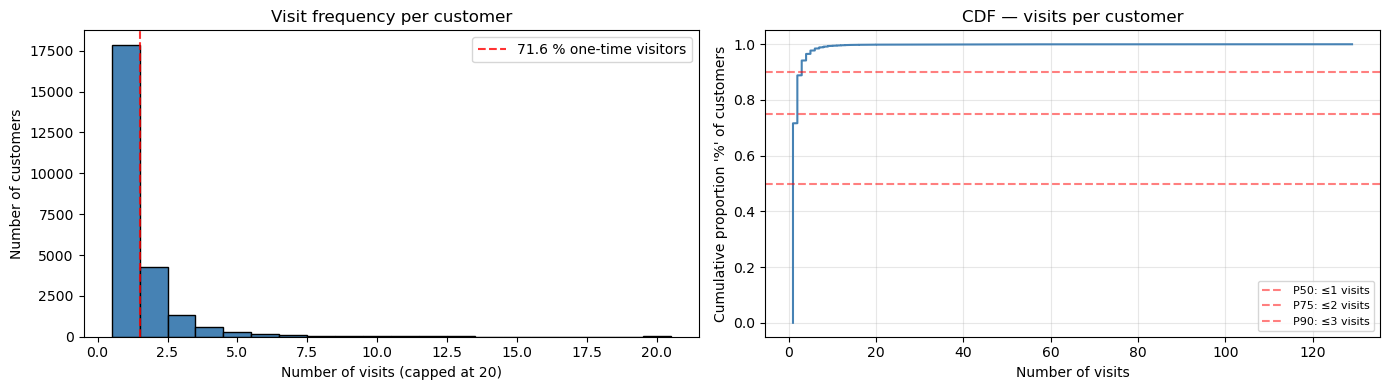

Unique customers       : 24,936
One-time visitors      : 17,859  (71.6%)
Repeat visitors (2+)   : 7,077

Visits-per-customer stats:
count    24936.0
mean         1.6
std          2.3
min          1.0
25%          1.0
50%          1.0
75%          2.0
max        129.0
dtype: float64


In [8]:
# ── EDA 2.1: Visits per Customer ──────────────────────────
# Check distribution of visits per customer - highly skewed, 
# with many one-time visitors and a long tail of repeat visitors

visits_per_cust = visits_sorted.groupby("customer_id").size()
# Histogram Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(visits_per_cust.clip(upper=20), bins=range(1, 22), edgecolor="k", color="steelblue", align="left")
axes[0].set_xlabel("Number of visits (capped at 20)")
axes[0].set_ylabel("Number of customers")
axes[0].set_title("Visit frequency per customer")
axes[0].axvline(1.5, color="red", linestyle="--", alpha=0.8,
                label=f"{(visits_per_cust == 1).mean() * 100:.1f} % one-time visitors")
axes[0].legend()

# CDF Plot
sv = np.sort(visits_per_cust.values)
cdf = np.arange(1, len(sv) + 1) / len(sv)
axes[1].plot(sv, cdf, color="steelblue")
axes[1].set_xlabel("Number of visits")
axes[1].set_ylabel("Cumulative proportion '%' of customers")
axes[1].set_title("CDF — visits per customer")
axes[1].grid(True, alpha=0.3)
for pct in [0.5, 0.75, 0.9]:
    
    thresh = int(np.percentile(sv, pct * 100))
    axes[1].axhline(pct, color="red", linestyle="--", alpha=0.5,
                    label=f"P{int(pct*100)}: ≤{thresh} visits")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Print the data
print(f"Unique customers       : {len(visits_per_cust):,}")
print(f"One-time visitors      : {(visits_per_cust == 1).sum():,}  ({(visits_per_cust == 1).mean() * 100:.1f}%)")
print(f"Repeat visitors (2+)   : {(visits_per_cust >= 2).sum():,}")
print(f"\nVisits-per-customer stats:")
print(visits_per_cust.describe().round(1))

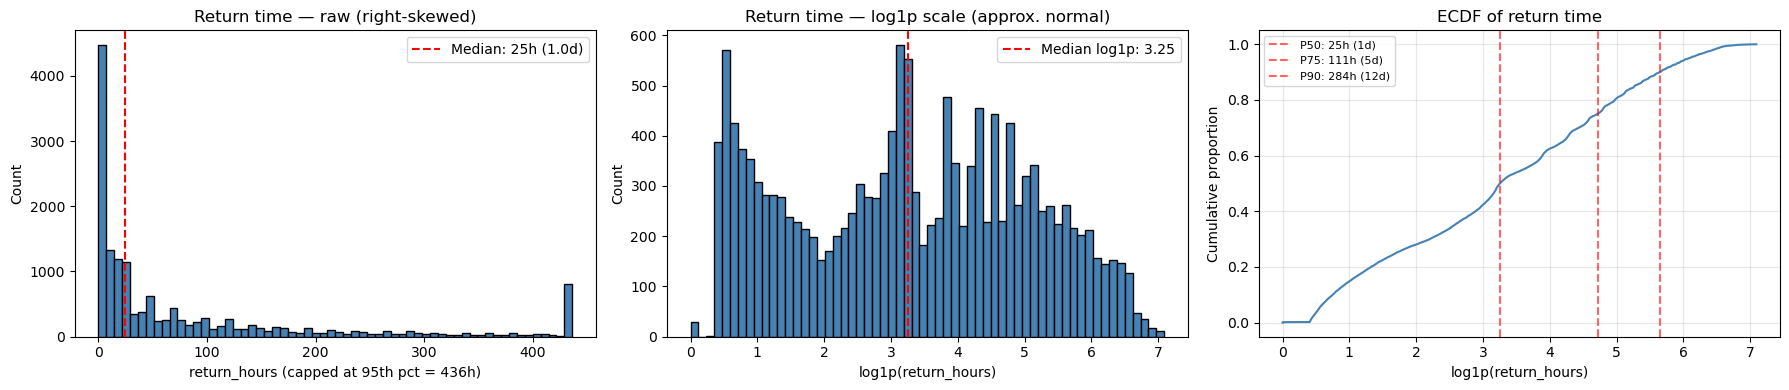

return_hours percentiles:
  P10:      1.1h  =  0.0 days
  P25:      4.5h  =  0.2 days
  P50:     24.9h  =  1.0 days
  P75:    110.7h  =  4.6 days
  P90:    283.6h  =  11.8 days
  P95:    436.0h  =  18.2 days
  P99:    714.4h  =  29.8 days


In [9]:
# ── EDA 2.2: Return Time Distribution ──────────────────────────
# Check distribution of target variable (return_hours) - highly skewed, 
# so log-transform is needed for modelling

return_cust = visits_sorted.loc[visits_sorted["return_hours"].notna(),"return_hours"].copy()
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
cap95 = return_cust.quantile(0.95)
axes[0].hist(return_cust.clip(upper=cap95), bins=60, edgecolor="k", color="steelblue")
axes[0].axvline(return_cust.median(), color="red", linestyle="--",
                label=f"Median: {return_cust.median():.0f}h ({return_cust.median()/24:.1f}d)")
axes[0].set_xlabel(f"return_hours (capped at 95th pct = {cap95:.0f}h)")
axes[0].set_ylabel("Count")
axes[0].set_title("Return time — raw (right-skewed)")
axes[0].legend()

# Log1p scale
log_rt = np.log1p(return_cust)
axes[1].hist(log_rt, bins=60, edgecolor="k", color="steelblue")
axes[1].axvline(log_rt.median(), color="red", linestyle="--",
                label=f"Median log1p: {log_rt.median():.2f}")
axes[1].set_xlabel("log1p(return_hours)")
axes[1].set_ylabel("Count")
axes[1].set_title("Return time — log1p scale (approx. normal)")
axes[1].legend()

# ECDF
sv = np.sort(return_cust.values)
cdf = np.arange(1, len(sv) + 1) / len(sv)
axes[2].plot(np.log1p(sv), cdf, color="steelblue")
for q, label in [(0.5, "P50"), (0.75, "P75"), (0.9, "P90")]:
    val = return_cust.quantile(q)
    axes[2].axvline(np.log1p(val), color="red", linestyle="--", alpha=0.6,
                    label=f"{label}: {val:.0f}h ({val/24:.0f}d)")
axes[2].set_xlabel("log1p(return_hours)")
axes[2].set_ylabel("Cumulative proportion")
axes[2].set_title("ECDF of return time")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("return_hours percentiles:")
for p in [10, 25, 50, 75, 90, 95, 99]:
    v = return_cust.quantile(p / 100)
    print(f"  P{p:2d}: {v:8.1f}h  =  {v/24:.1f} days")

/tmp/ipykernel_26353/649902210.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(


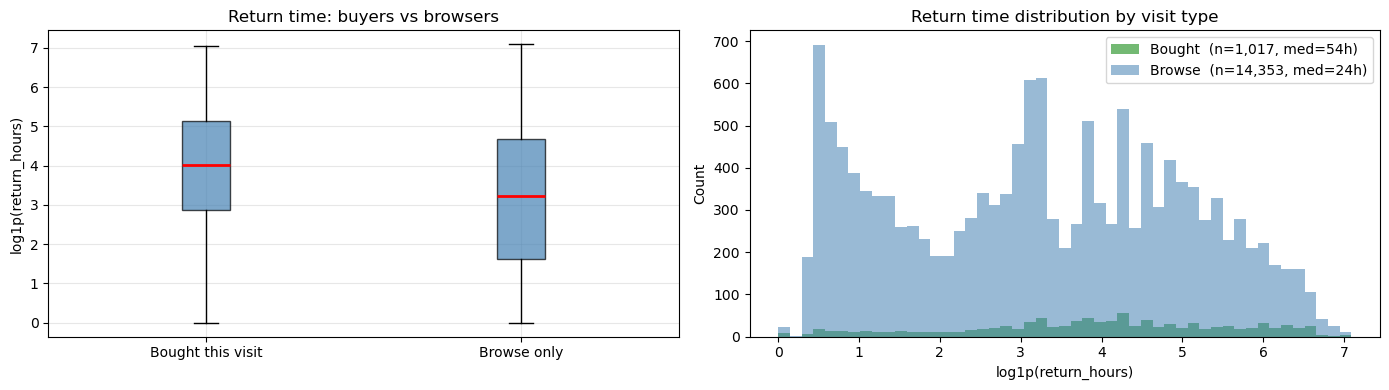

Median return — bought this visit : 54.4h  (2.3 days)
Median return — browse only       : 23.9h  (1.0 days)
Buyers return 30.5h longer on average


In [10]:
# ── EDA 2.3: Do buyers return sooner than browsers? ──────────────────────────
rt_data = visits_sorted[visits_sorted["return_hours"].notna()].copy()
buyer_rt   = rt_data.loc[rt_data["visit_bought_flag"],  "return_hours"]
browser_rt = rt_data.loc[~rt_data["visit_bought_flag"], "return_hours"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Side-by-side boxplot (log scale)
axes[0].boxplot(
    [np.log1p(buyer_rt.values), np.log1p(browser_rt.values)],
    labels=["Bought this visit", "Browse only"],
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.7),
    medianprops=dict(color="red", linewidth=2),
)
axes[0].set_ylabel("log1p(return_hours)")
axes[0].set_title("Return time: buyers vs browsers")
axes[0].grid(True, alpha=0.3)

# Overlapping histograms (log scale)
bins = np.linspace(0, max(np.log1p(buyer_rt).max(), np.log1p(browser_rt).max()), 50)
axes[1].hist(np.log1p(buyer_rt),   bins=bins, alpha=0.55, color="green",
             label=f"Bought  (n={len(buyer_rt):,}, med={buyer_rt.median():.0f}h)")
axes[1].hist(np.log1p(browser_rt), bins=bins, alpha=0.55, color="steelblue",
             label=f"Browse  (n={len(browser_rt):,}, med={browser_rt.median():.0f}h)")
axes[1].set_xlabel("log1p(return_hours)")
axes[1].set_ylabel("Count")
axes[1].set_title("Return time distribution by visit type")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Median return — bought this visit : {buyer_rt.median():.1f}h  ({buyer_rt.median()/24:.1f} days)")
print(f"Median return — browse only       : {browser_rt.median():.1f}h  ({browser_rt.median()/24:.1f} days)")
diff = buyer_rt.median() - browser_rt.median()
direction = "shorter" if diff < 0 else "longer"
print(f"Buyers return {abs(diff):.1f}h {direction} on average")


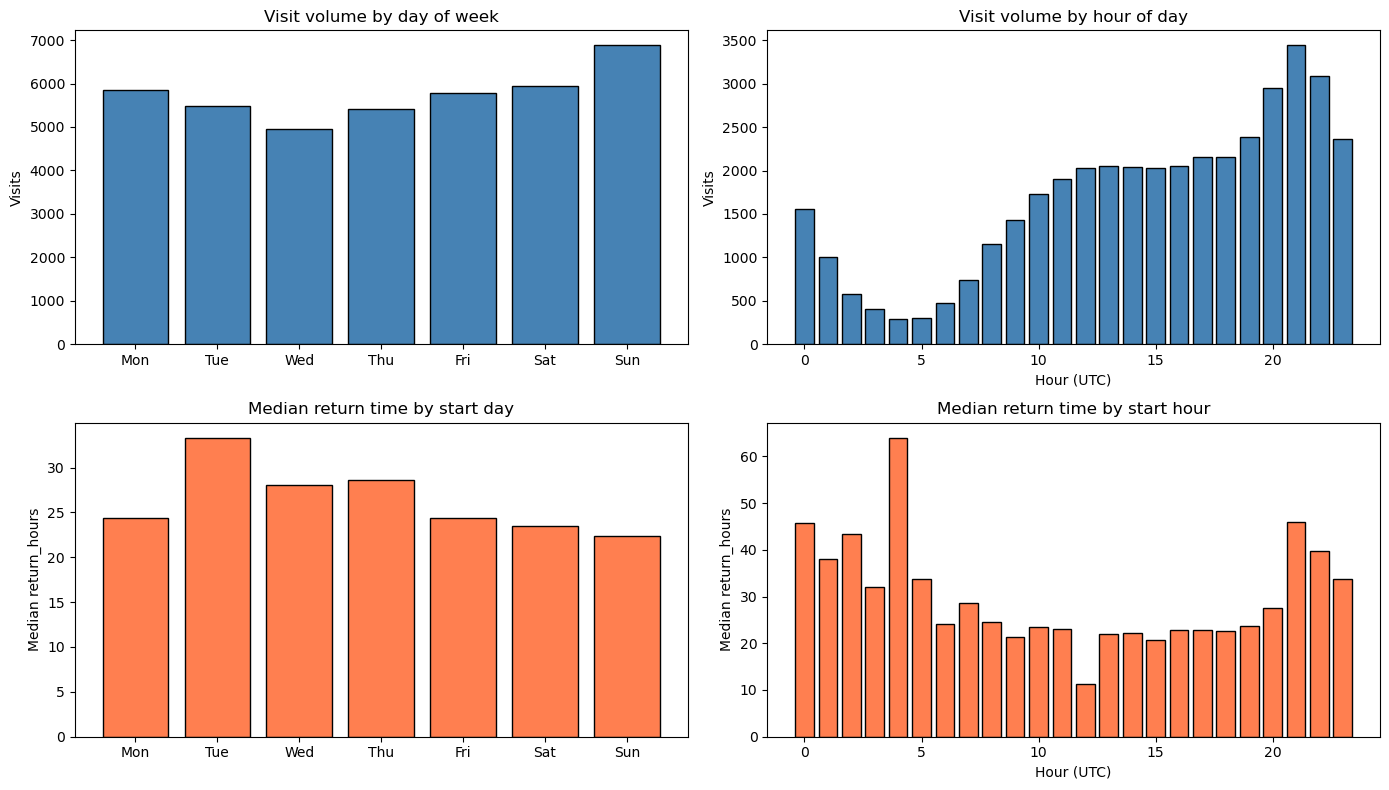

In [11]:
# ── EDA 2.4: Day-of-week and hour-of-day patterns ─────────────────────────────
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Visit volume

## by day
dow_count = visits_sorted["start_dayofweek"].value_counts().sort_index()
axes[0, 0].bar(range(1, 8), [dow_count.get(i, 0) for i in range(1, 8)],
               color="steelblue", edgecolor="k")
axes[0, 0].set_xticks(range(1, 8)); axes[0, 0].set_xticklabels(day_labels)
axes[0, 0].set_title("Visit volume by day of week"); axes[0, 0].set_ylabel("Visits")

## by hour
hr_count = visits_sorted["start_hour"].value_counts().sort_index()
axes[0, 1].bar(range(24), [hr_count.get(i, 0) for i in range(24)],
               color="steelblue", edgecolor="k")
axes[0, 1].set_xlabel("Hour (UTC)"); axes[0, 1].set_title("Visit volume by hour of day")
axes[0, 1].set_ylabel("Visits")

# Median return time 

## by day
return_time_dow = rt_data.groupby("start_dayofweek")["return_hours"].median()
axes[1, 0].bar(range(1, 8), [return_time_dow.get(i, 0) for i in range(1, 8)],
               color="coral", edgecolor="k")
axes[1, 0].set_xticks(range(1, 8)); axes[1, 0].set_xticklabels(day_labels)
axes[1, 0].set_title("Median return time by start day"); axes[1, 0].set_ylabel("Median return_hours")

## by hour
return_time_hr = rt_data.groupby("start_hour")["return_hours"].median()
axes[1, 1].bar(range(24), [return_time_hr.get(i, 0) for i in range(24)],
               color="coral", edgecolor="k")
axes[1, 1].set_xlabel("Hour (UTC)"); axes[1, 1].set_title("Median return time by start hour")
axes[1, 1].set_ylabel("Median return_hours")

plt.tight_layout()
plt.show()


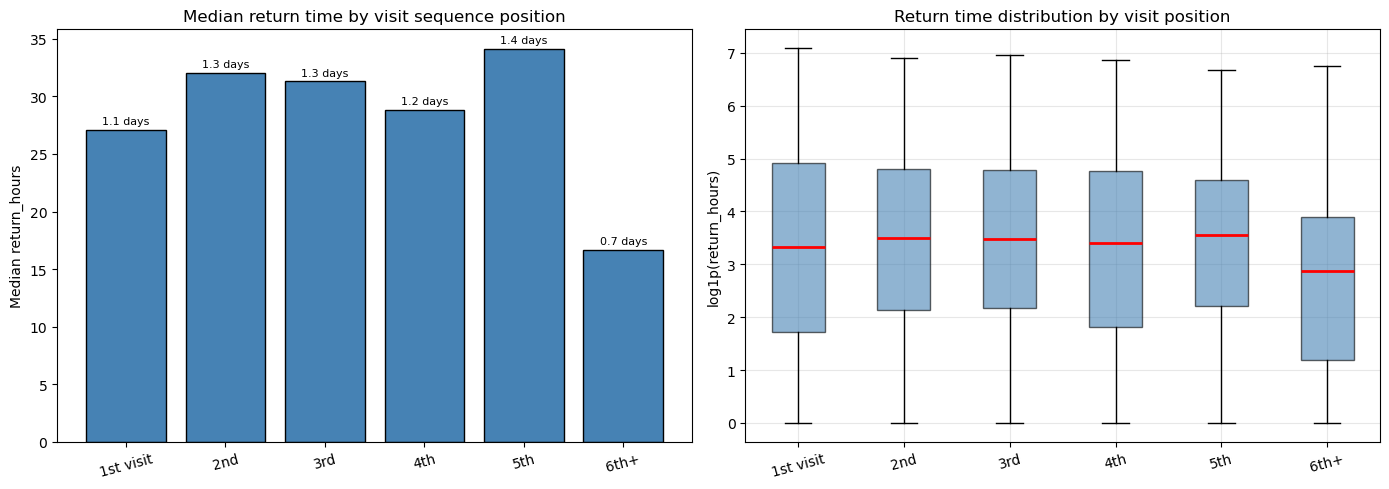

Median return_hours by visit sequence position:
	1st visit :   27.1h  (1.1 days)   n=7,077
	2nd       :   32.0h  (1.3 days)   n=2,787
	3rd       :   31.3h  (1.3 days)   n=1,458
	4th       :   28.9h  (1.2 days)   n=868
	5th       :   34.1h  (1.4 days)   n=565
	6th+      :   16.7h  (0.7 days)   n=2,615


In [12]:
# ── EDA 2.5: Return time by visit sequence number ─────────────────────────────
# Do first-time returners come back faster or slower than long-term regulars?

# Cap visit_index for readability (group 5+ as "5+")
rt_data["visit_index_capped"] = rt_data["visit_counter_index"].clip(upper=5)
idx_labels = {0: "1st visit", 1: "2nd", 2: "3rd", 3: "4th", 4: "5th", 5: "6th+"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Median return time (hour --> day) per sequence position
median_by_index = rt_data.groupby("visit_index_capped")["return_hours"].median()
axes[0].bar(median_by_index.index, median_by_index.values, color="steelblue", edgecolor="k")
axes[0].set_xticks(list(idx_labels.keys()))
axes[0].set_xticklabels(list(idx_labels.values()), rotation=15)
axes[0].set_ylabel("Median return_hours")
axes[0].set_title("Median return time by visit sequence position")
for i, v in median_by_index.items():
    axes[0].text(i, v + 0.5, f"{v/24:.1f} days", ha="center", fontsize=8)

# Boxplot (log scale) per sequence position
groups = [
    np.log1p(rt_data.loc[rt_data["visit_index_capped"] == k, "return_hours"].values)
    for k in sorted(idx_labels.keys())
]
axes[1].boxplot(groups, tick_labels=list(idx_labels.values()),
                patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6),
                medianprops=dict(color="red", linewidth=2))
axes[1].set_ylabel("log1p(return_hours)")
axes[1].set_title("Return time distribution by visit position")
axes[1].tick_params(axis="x", rotation=15)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Median return_hours by visit sequence position:")
for k, v in median_by_index.items():
    n = (rt_data["visit_index_capped"] == k).sum()
    print(f"\t{idx_labels[k]:<10}: {v:6.1f}h  ({v/24:.1f} days)   n={n:,}")


___
## Step 3 — Feature Engineering

**AIM:**
- Construct a leak-safe feature set that captures both within-session behaviour and inter-visit history

**APPROACH:**
- **Session features**: what happened in this visit (products viewed/bought/carted, time spent, hour of day)
- **Recency features**: how long since the last visit (`prev_gap_hours`), what the previous visit looked like
- **Rolling history**: 3-visit rolling averages of gap, time spent, and products viewed
- **Purchase history**: cumulative buy rate and `ever_bought` flag — always computed from *past* visits only via `shift(1)` to prevent leakage
- **Sequence position**: `visit_counter_index` captures where in the customer lifecycle this visit falls

In [13]:
feature_engineered_df = visits_sorted.copy()

# convert column "time_Spent_in_minutes" from `timedelta` --> `float`
feature_engineered_df["time_spent_in_minutes"] = \
        feature_engineered_df["time_spent_in_minutes"].dt.total_seconds() / 60

# add features for buy and cart ratios
feature_engineered_df["buy_ratio"]  = \
        (feature_engineered_df["total_bought_products"] /
         feature_engineered_df["total_viewed_products"]
         ).where(feature_engineered_df["total_viewed_products"] > 0, 0.0)

feature_engineered_df["cart_ratio"] = \
        (feature_engineered_df["total_put_in_cart_products"] /
         feature_engineered_df["total_viewed_products"]
        ).where(feature_engineered_df["total_viewed_products"] > 0, 0.0)

# cumulative purchase history
grouped_by_bought_flag = feature_engineered_df.groupby("customer_id")["visit_bought_flag"]

feature_engineered_df["ever_bought"] = \
        grouped_by_bought_flag \
        .shift(1) \
        .fillna(False) \
        .astype(bool) \
        .groupby(feature_engineered_df["customer_id"]) \
        .cummax() \
        .astype(int)

feature_engineered_df["cumulative_bought_visits"] = \
        grouped_by_bought_flag \
        .shift(1) \
        .fillna(False) \
        .astype(bool) \
        .groupby(feature_engineered_df["customer_id"]) \
        .cumsum() \
        .astype(int)

# visit sequence
feature_engineered_df["past_visits_count"] = feature_engineered_df["visit_counter_index"]

# cumulative buy rate
feature_engineered_df["cumulative_buy_rate"] = \
        (feature_engineered_df["cumulative_bought_visits"] / 
         feature_engineered_df["past_visits_count"]
        ).where(feature_engineered_df["past_visits_count"] > 0)

feature_engineered_df.head()

,customer_id,visit_counter_index,start_dt,start_hour,start_dayofweek,end_dt,time_spent_in_minutes,num_of_times_search_was_used,total_viewed_products,total_bought_products,total_put_in_cart_products,visit_bought_flag,return_hours,visit_is_this_last,buy_ratio,cart_ratio,ever_bought,cumulative_bought_visits,past_visits_count,cumulative_buy_rate
0,0,0,2024-07-28 18:55:46.130,18,7,2024-07-28 19:01:13.940,5.463450,0,1,2,0,True,NaN,True,2.0,0.0,0,0,0,NaN
1,1,0,2024-08-17 22:47:27.310,22,6,2024-08-17 22:47:46.300,0.316483,0,1,0,0,False,NaN,True,0.0,0.0,0,0,0,NaN
2,2,0,2024-07-21 22:24:26.240,22,7,2024-07-21 22:24:34.460,0.136967,0,0,0,1,False,NaN,True,0.0,0.0,0,0,0,NaN
3,3,0,2024-08-25 07:10:16.140,7,7,2024-08-25 07:17:40.550,7.406667,0,1,0,1,False,5.805639,False,0.0,1.0,0,0,0,NaN
4,3,1,2024-08-25 13:06:00.850,13,7,2024-08-25 13:18:58.850,12.966617,1,3,0,3,False,9.904131,False,0.0,1.0,0,0,1,0.0


In [14]:
# lag features
feature_engineered_df["prev_end_dt"]       = feature_engineered_df.groupby("customer_id")["end_dt"].shift(1)
feature_engineered_df["prev_time_spent"]   = feature_engineered_df.groupby("customer_id")["time_spent_in_minutes"].shift(1)
feature_engineered_df["prev_search_count"] = feature_engineered_df.groupby("customer_id")["num_of_times_search_was_used"].shift(1)
feature_engineered_df["prev_viewed_count"] = feature_engineered_df.groupby("customer_id")["total_viewed_products"].shift(1)
feature_engineered_df["prev_bought"]       = feature_engineered_df.groupby("customer_id")["visit_bought_flag"    ].shift(1).astype(float)
feature_engineered_df["prev_gap_hours"]    = ((feature_engineered_df["start_dt"] - feature_engineered_df["prev_end_dt"]
                                               ).dt.total_seconds() /3600
                                             ).clip(lower=0)

# rolling averages over last 3 past visits
moving_avg_func = lambda s: s.rolling(3, min_periods=1).mean()
feature_engineered_df["rolling_avg_gap"] = \
        feature_engineered_df.groupby("customer_id")["prev_gap_hours"].transform(moving_avg_func)

feature_engineered_df["rolling_avg_time_spent"] = \
        feature_engineered_df.groupby("customer_id")["prev_time_spent"].transform(moving_avg_func)

feature_engineered_df["rolling_avg_viewed"] = \
        feature_engineered_df.groupby("customer_id")["prev_viewed_count"].transform(moving_avg_func)

# excluding current visit gap by shift(1)
expanding_mean_func = lambda s: s.expanding().mean()
feature_engineered_df["cumulative_avg_gap"] = \
        feature_engineered_df.groupby("customer_id")["prev_gap_hours"] \
                             .shift(1) \
                             .groupby(feature_engineered_df["customer_id"]) \
                             .transform(expanding_mean_func)

print("Feature engineering complete. fe.shape:", feature_engineered_df.shape)
feature_engineered_df.head()

Feature engineering complete. fe.shape: (40306, 30)


,customer_id,visit_counter_index,start_dt,start_hour,start_dayofweek,end_dt,time_spent_in_minutes,num_of_times_search_was_used,total_viewed_products,total_bought_products,total_put_in_cart_products,visit_bought_flag,return_hours,visit_is_this_last,buy_ratio,cart_ratio,ever_bought,cumulative_bought_visits,past_visits_count,cumulative_buy_rate,prev_end_dt,prev_time_spent,prev_search_count,prev_viewed_count,prev_bought,prev_gap_hours,rolling_avg_gap,rolling_avg_time_spent,rolling_avg_viewed,cumulative_avg_gap
0,0,0,2024-07-28 18:55:46.130,18,7,2024-07-28 19:01:13.940,5.463450,0,1,2,0,True,NaN,True,2.0,0.0,0,0,0,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,0,2024-08-17 22:47:27.310,22,6,2024-08-17 22:47:46.300,0.316483,0,1,0,0,False,NaN,True,0.0,0.0,0,0,0,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,0,2024-07-21 22:24:26.240,22,7,2024-07-21 22:24:34.460,0.136967,0,0,0,1,False,NaN,True,0.0,0.0,0,0,0,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,0,2024-08-25 07:10:16.140,7,7,2024-08-25 07:17:40.550,7.406667,0,1,0,1,False,5.805639,False,0.0,1.0,0,0,0,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3,1,2024-08-25 13:06:00.850,13,7,2024-08-25 13:18:58.850,12.966617,1,3,0,3,False,9.904131,False,0.0,1.0,0,0,1,0.0,2024-08-25 07:17:40.550,7.406667,0.0,1.0,0.0,5.805639,5.805639,7.406667,1.0,NaN


In [15]:
## Showing sample of the engineered features for repeat customer
## - visited more than 3 times 
## - first such customer in the dataset

repeat_custsample = feature_engineered_df.groupby("customer_id")["visit_counter_index"].max()
repeat_custsample = repeat_custsample[repeat_custsample >= 3].index[0]
demo_cols = [
    "visit_counter_index", "start_dt", "end_dt",
    "visit_bought_flag", "ever_bought", "cumulative_bought_visits", "cumulative_buy_rate",
    "prev_gap_hours", "cumulative_avg_gap", "return_hours",
]
print(f"Sample rows for customer {repeat_custsample}:\n")
print(feature_engineered_df[
                            feature_engineered_df["customer_id"] == repeat_custsample
                           ][demo_cols] \
                           .to_string(index=False))


Sample rows for customer 3:

 visit_counter_index                start_dt                  end_dt  visit_bought_flag  ever_bought  cumulative_bought_visits  cumulative_buy_rate  prev_gap_hours  cumulative_avg_gap  return_hours
                   0 2024-08-25 07:10:16.140 2024-08-25 07:17:40.550              False            0                         0                  NaN             NaN                 NaN      5.805639
                   1 2024-08-25 13:06:00.850 2024-08-25 13:18:58.850              False            0                         0                  0.0        5.805639                 NaN      9.904131
                   2 2024-08-25 23:13:13.720 2024-08-26 00:14:41.850              False            0                         0                  0.0        9.904131            5.805639     19.142839
                   3 2024-08-26 19:23:16.070 2024-08-26 19:30:49.780              False            0                         0                  0.0       19.142839            7.85

___
## Step 4 — Modelling

**AIM:**
- Find the model that best predicts `return_hours` on held-out validation data under a chronological split

**APPROACH:**
- Chronological 80/20 split on `end_dt` to simulate real deployment conditions (no future leakage)
- Establish median baselines before adding model complexity
- Train on `log1p(return_hours)` to reduce skew influence; invert with `expm1` at evaluation time
- Optimise MAE directly (more interpretable than RMSE for right-skewed targets)
- Compare: HGB → RandomForest → XGBoost → LightGBM DART, each with consistent hyperparameter philosophy

### 4.1 Data Splitting

In [16]:
# build model dataset + chronological train/val split
FEATURE_COLS = [
    # within-session
    "total_viewed_products",
    "total_put_in_cart_products",
    "total_bought_products",
    "num_of_times_search_was_used",
    "time_spent_in_minutes",
    "buy_ratio",
    "cart_ratio",
    "start_hour",
    "start_dayofweek",
    "visit_bought_flag",
    # sequence
    "visit_counter_index",
    # purchase history
    "ever_bought",
    "cumulative_bought_visits",
    "cumulative_buy_rate",
    # lag / recency
    "prev_gap_hours",
    "prev_time_spent",
    "prev_search_count",
    "prev_viewed_count",
    "prev_bought",
    # rolling averages
    "rolling_avg_gap",
    "rolling_avg_time_spent",
    "rolling_avg_viewed",
    # customer-level
    "cumulative_avg_gap",
]

# drop rows with no target (last visit per customer)
model_df = feature_engineered_df[feature_engineered_df["return_hours"].notna()].copy() 

# chronological 80/20 split: train on earlier visits, validate on later
split_time = model_df["end_dt"].quantile(0.8)
train_df = model_df[model_df["end_dt"] <= split_time].copy()
val_df   = model_df[model_df["end_dt"]  > split_time].copy()
X_train = train_df[FEATURE_COLS]
X_val   = val_df[FEATURE_COLS]
y_train = train_df["return_hours"]
y_val   = val_df["return_hours"]

start_time = model_df["end_dt"].min()
end_time   = model_df["end_dt"].max()

excluded = len(feature_engineered_df) - len(model_df)
print(f"Features     : {len(FEATURE_COLS)}")
print(f"Model rows   : {len(model_df):,}  (excluded {excluded:,} last-visit rows)")
print(f"Split time   : {start_time} — {split_time} — {end_time}")
print(f"Train rows   : {len(train_df):,}")
print(f"Val rows     : {len(val_df):,}")
print("\n")
print(f"y_train stats:\n"); print(y_train.describe().round(1))

Features     : 23
Model rows   : 15,370  (excluded 24,936 last-visit rows)
Split time   : 2024-07-20 12:12:28.040000 — 2024-08-27 19:11:42.482000 — 2024-09-09 01:12:17.330000
Train rows   : 12,296
Val rows     : 3,074


y_train stats:

count    12296.0
mean       108.3
std        166.7
min          0.0
25%          5.4
50%         30.9
75%        135.4
max       1198.7
Name: return_hours, dtype: float64


In [17]:
# drift check: is the val period just different?
train_median = y_train.median()
val_median   = y_val.median()
drift_pct    = abs(val_median - train_median) / train_median * 100
print("── Target distribution: train vs val (DRIFT DETECTION) ───────────────────────────")
print(f"  Train median : {train_median:.1f}h  ({train_median/24:.1f}d)")
print(f"  Val   median : {val_median:.1f}h  ({val_median/24:.1f}d)")
print(f"  Drift        : {drift_pct:.1f}%\n")

if drift_pct > 10:
    print("  ⚠ Significant target drift detected — the val period has a")
    print("     different return-time distribution than train. This alone")
    print("     can widen MAE independently of model quality.")
else:
    print("  ✓  Target distributions are similar; drift is not a major factor.")

print(f"\n  Train date range: {train_df['start_dt'].min().date()} → {train_df['start_dt'].max().date()}")
print(f"  Val   date range: {val_df['start_dt'].min().date()} → {val_df['start_dt'].max().date()}")

── Target distribution: train vs val (DRIFT DETECTION) ───────────────────────────
  Train median : 30.9h  (1.3d)
  Val   median : 15.8h  (0.7d)
  Drift        : 48.7%

  ⚠ Significant target drift detected — the val period has a
     different return-time distribution than train. This alone
     can widen MAE independently of model quality.

  Train date range: 2024-07-20 → 2024-08-27
  Val   date range: 2024-08-27 → 2024-09-09


### 4.2 Plotting Splitted dataset for distribution check

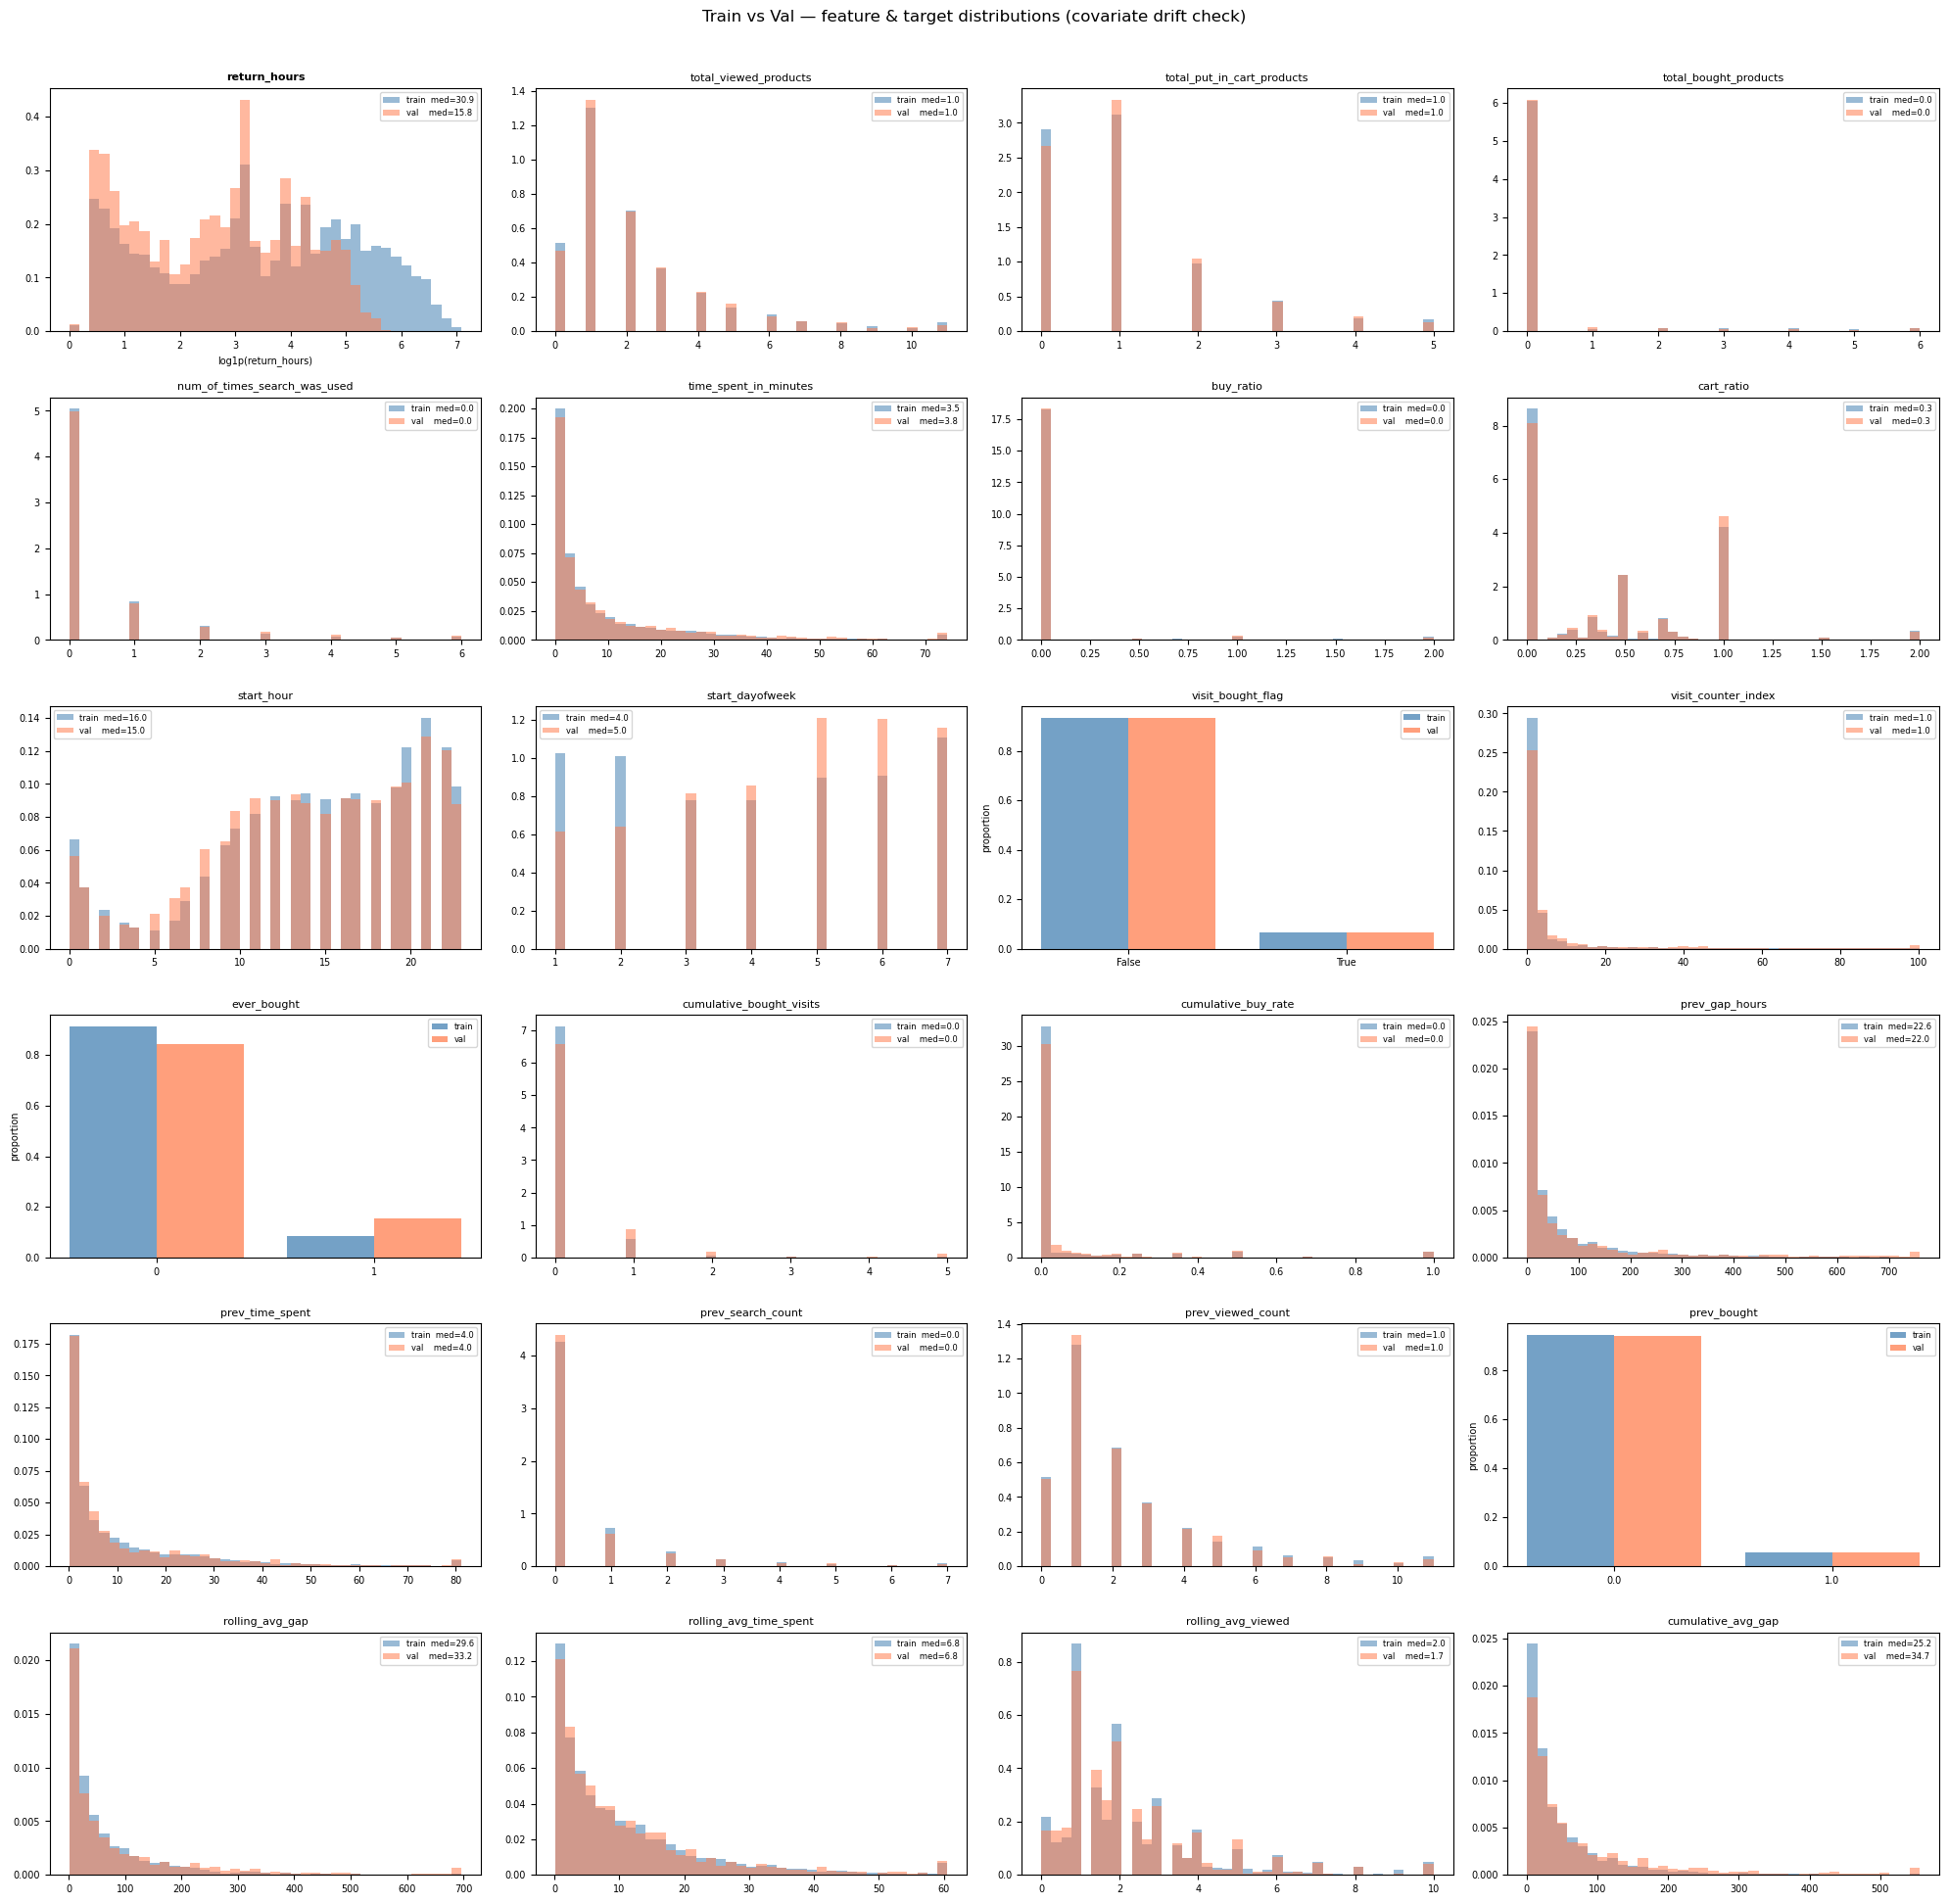

In [18]:
# ── feature distributions train vs val ──────────────────────

binary_cols = {"visit_bought_flag", "ever_bought", "prev_bought"}
plot_cols   = ["return_hours"] + FEATURE_COLS

# plot dimentions 
n_cols = 4
n_rows = math.ceil(len(plot_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.2))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    ax       = axes[i]
    is_target = col == "return_hours"
    train_s  = y_train.dropna()        if is_target else X_train[col].dropna()
    val_s    = y_val.dropna()          if is_target else X_val[col].dropna()

    if col in binary_cols or train_s.nunique() <= 3:
        # binary / low-cardinality → proportions bar chart
        categories = sorted(set(train_s.unique()) | set(val_s.unique()))

        x = np.arange(len(categories))

        ax.bar(x - 0.2, [(train_s == c).mean() for c in categories], 0.4,
               label="train", color="steelblue", alpha=0.75)
        ax.bar(x + 0.2, [(val_s   == c).mean() for c in categories], 0.4,
               label="val",   color="coral",     alpha=0.75)
        ax.set_xticks(x)
        ax.set_xticklabels([str(c) for c in categories], fontsize=7)
        ax.set_ylabel("proportion", fontsize=7)

    else:
        # continuous → overlapping histograms
        if is_target:
            t_plot, v_plot = np.log1p(train_s), np.log1p(val_s)
            ax.set_xlabel("log1p(return_hours)", fontsize=7)

        else:
            lo     = min(train_s.quantile(0.01), val_s.quantile(0.01))
            hi     = max(train_s.quantile(0.99), val_s.quantile(0.99))
            t_plot = train_s.clip(lo, hi)
            v_plot = val_s.clip(lo, hi)
        bins = np.linspace(
            min(t_plot.min(), v_plot.min()),
            max(t_plot.max(), v_plot.max()), 40
        )
        ax.hist(t_plot, bins=bins, alpha=0.55, color="steelblue", density=True,
                label=f"train  med={train_s.median():.1f}")
        ax.hist(v_plot, bins=bins, alpha=0.55, color="coral",     density=True,
                label=f"val    med={val_s.median():.1f}")

    ax.set_title(col, fontsize=8, fontweight="bold" if is_target else "normal")
    ax.legend(fontsize=6)
    ax.tick_params(labelsize=7)

for j in range(len(plot_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Train vs Val — feature & target distributions (covariate drift check)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### 4.3 Baseline determination

In [19]:
# baseline: global median
median_global = y_train.median()
baseline_preds = np.full(len(y_val), median_global)
print("── Global Median Baseline ──────────────────────────────────────")
print(f"  Prediction value : {median_global:.1f}h  ({median_global/24:.1f} days)")
print(f"  MAE              : {mae(y_val, baseline_preds):.2f}h")
print(f"  RMSE             : {rmse(y_val, baseline_preds):.2f}h")

# segment-aware baseline: median per (ever_bought × start_dayofweek)
seg_medians = (
    train_df.groupby(["ever_bought", "start_dayofweek"])["return_hours"]
    .median()
    .rename("seg_median")
)
val_seg = val_df[["ever_bought", "start_dayofweek"]].join(
    seg_medians, on=["ever_bought", "start_dayofweek"]
)
val_seg["seg_median"] = val_seg["seg_median"].fillna(median_global)
seg_preds = val_seg["seg_median"].values

print("\n── Segmented Median Baseline (ever_bought × day-of-week) ──────")
print(f"  MAE  : {mae(y_val, seg_preds):.2f}h")
print(f"  RMSE : {rmse(y_val, seg_preds):.2f}h")

── Global Median Baseline ──────────────────────────────────────
  Prediction value : 30.9h  (1.3 days)
  MAE              : 32.32h
  RMSE             : 2078.08h

── Segmented Median Baseline (ever_bought × day-of-week) ──────
  MAE  : 32.71h
  RMSE : 2087.12h


### 4.4 Modelling

#### 4.4.1 HGB Modelling

── HistGradientBoosting (log1p target, MAE loss) ────────────────────────
  MAE  : 36.11h
  RMSE : 2505.10h

── Summary comparison ───────────────────────────────────────────────────
	Model                                    MAE     RMSE
	-----------------------------------------------------------------
	Global Median Baseline             	   32.32	 2078.08
	Segmented Median (ever_bought × dow)	   32.71	 2087.12
	HGB (23 features, log1p/MAE loss)  	   36.11	 2505.10


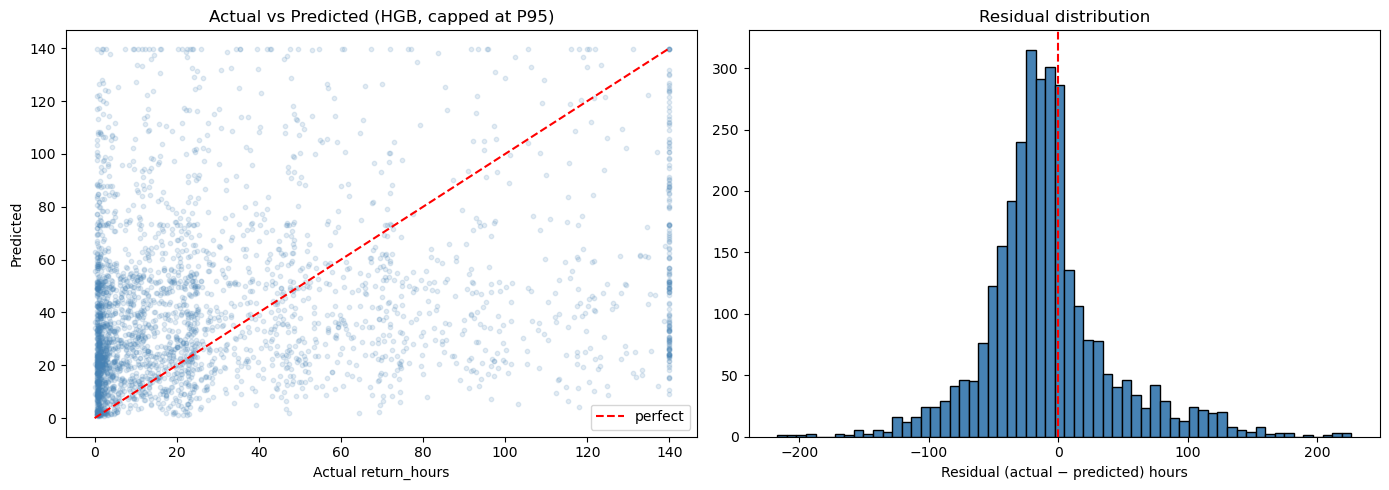

In [20]:
# handles NaNs natively

y_train_log = np.log1p(y_train)
hgb = HistGradientBoostingRegressor(
    loss="absolute_error",
    learning_rate=0.05,
    max_iter=400,
    max_depth=6,
    min_samples_leaf=30,
    random_state=42,
)
hgb.fit(X_train, y_train_log)

# Predict and invert log transform; clipped to 0
preds_log = hgb.predict(X_val)
preds_hgb = np.expm1(preds_log).clip(min=0)
print("── HistGradientBoosting (log1p target, MAE loss) ────────────────────────")
print(f"  MAE  : {mae(y_val, preds_hgb):.2f}h")
print(f"  RMSE : {rmse(y_val, preds_hgb):.2f}h")

# check if the val period just has a different distribution than train
print("\n── Summary comparison ───────────────────────────────────────────────────")
print(f"\t{'Model':<35} {'MAE':>8} {'RMSE':>8}")
print(f"\t{'-'*65}")
print(f"\t{'Global Median Baseline':<35}\t{mae(y_val, baseline_preds):>8.2f}\t{rmse(y_val, baseline_preds):>8.2f}")
print(f"\t{'Segmented Median (ever_bought × dow)':<35}\t{mae(y_val, seg_preds):>8.2f}\t{rmse(y_val, seg_preds):>8.2f}")
print(f"\t{'HGB (23 features, log1p/MAE loss)':<35}\t{mae(y_val, preds_hgb):>8.2f}\t{rmse(y_val, preds_hgb):>8.2f}")

# Actual vs predicted scatter (validation set)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cap_plot = np.percentile(y_val, 95)

axes[0].scatter(y_val.clip(upper=cap_plot), preds_hgb.clip(max=cap_plot),
                alpha=0.15, s=10, color="steelblue")
axes[0].plot([0, cap_plot], [0, cap_plot], "r--", linewidth=1.5, label="perfect")
axes[0].set_xlabel("Actual return_hours"); axes[0].set_ylabel("Predicted")
axes[0].set_title("Actual vs Predicted (HGB, capped at P95)")
axes[0].legend()

residuals = y_val.values - preds_hgb
axes[1].hist(residuals, bins=60, edgecolor="k", color="steelblue")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual (actual − predicted) hours")
axes[1].set_title("Residual distribution")

plt.tight_layout()
plt.show()

#### 4.4.2 Random Forest Modelling

Tuned RF val MAE: 32.00h
── RandomForest vs Baselines ────────────────────────────────────────────
  Model                                         MAE      MSE
  -----------------------------------------------------------------
  Global Median Baseline                      32.32  2078.08
  Segmented Median (ever_bought × dow)        32.71  2087.12
  RandomForest (log1p, median imputed)        32.00  2027.36


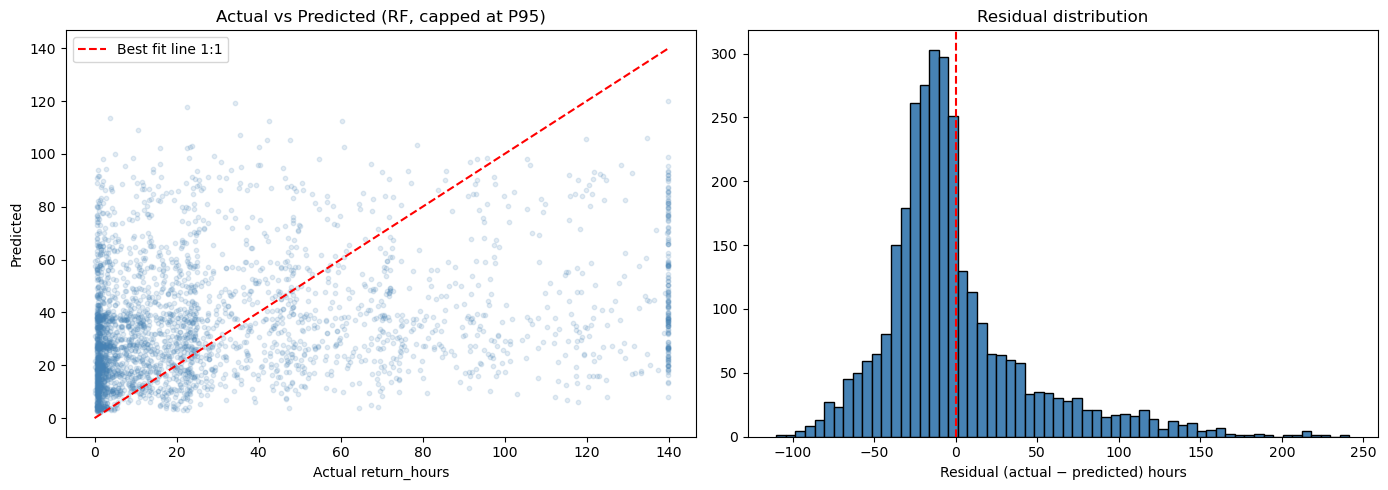

In [21]:
# ── 4.4.2 Random Forest Modelling ──────────────────────────────────────────────────

rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=500,
        max_depth=10,
        min_samples_leaf=10,
        max_features=0.5,
        n_jobs=-1,
        random_state=42,
    )),
])
rf_pipe.fit(X_train, y_train_log)
preds_rf = np.expm1(rf_pipe.predict(X_val)).clip(min=0)
print(f"Tuned RF val MAE: {mae(y_val, preds_rf):.2f}h")

print("── RandomForest vs Baselines ────────────────────────────────────────────")
print(f"  {'Model':<40} {'MAE':>8} {'MSE':>8}")
print(f"  {'-'*65}")
print(f"  {'Global Median Baseline':<40} {mae(y_val, baseline_preds):>8.2f} {rmse(y_val, baseline_preds):>8.2f}")
print(f"  {'Segmented Median (ever_bought × dow)':<40} {mae(y_val, seg_preds):>8.2f} {rmse(y_val, seg_preds):>8.2f}")
print(f"  {'RandomForest (log1p, median imputed)':<40} {mae(y_val, preds_rf):>8.2f} {rmse(y_val, preds_rf):>8.2f}")

# Actual vs predicted scatter (validation set)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cap_plot = np.percentile(y_val, 95)

axes[0].scatter(y_val.clip(upper=cap_plot), preds_rf.clip(max=cap_plot),
                alpha=0.15, s=10, color="steelblue")
axes[0].plot([0, cap_plot], [0, cap_plot], "r--", linewidth=1.5, label="Best fit line 1:1")
axes[0].set_xlabel("Actual return_hours"); axes[0].set_ylabel("Predicted")
axes[0].set_title("Actual vs Predicted (RF, capped at P95)")
axes[0].legend()

residuals = y_val.values - preds_rf
axes[1].hist(residuals, bins=60, edgecolor="k", color="steelblue")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual (actual − predicted) hours")
axes[1].set_title("Residual distribution")

plt.tight_layout()
plt.show()

#### 4.4.3 XGBoost

── XGBoost vs Baselines ─────────────────────────────────────────────────
  Model                                         MAE     RMSE
  --------------------------------------------------------
  Global Median Baseline                      32.32  2078.08
  Segmented Median (ever_bought × dow)        32.71  2087.12
  XGBoost (log1p, MAE objective)              36.06  2491.71


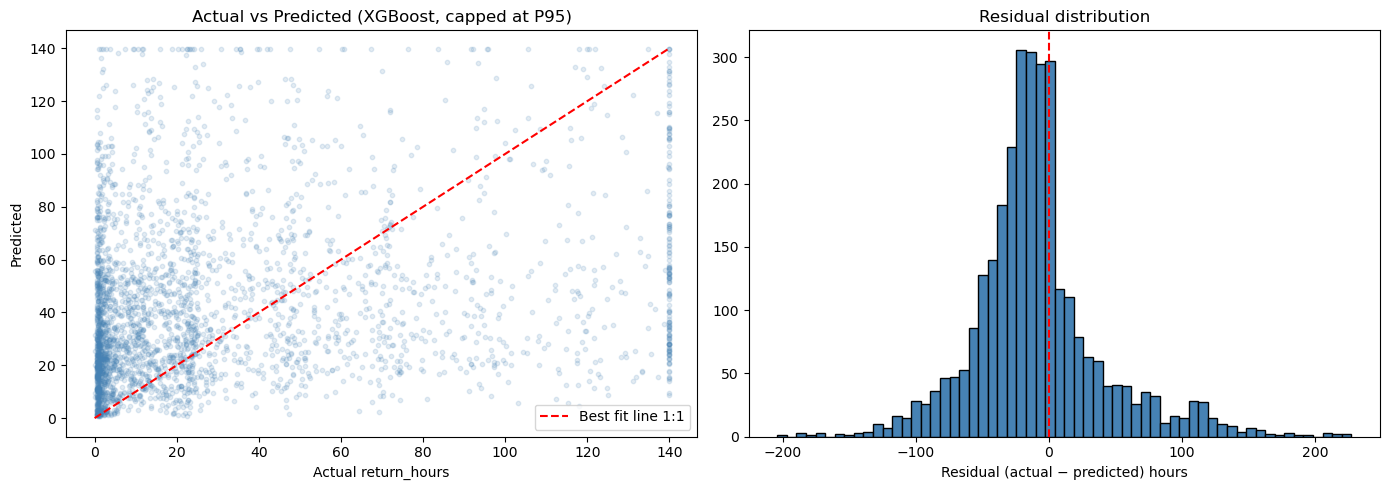

In [22]:
# ── 4.4.3 XGBoost Modelling ──────────────────────────────────────────────────

xgb_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   xgb.XGBRegressor(
        n_estimators=500,           # from grid search
        learning_rate=0.01,         # from grid search
        max_depth=8,                # from grid search
        min_child_weight=50,        # from grid search
        subsample=0.8,              # from grid search
        colsample_bytree=1.0,       # from grid search
        objective="reg:absoluteerror",
        n_jobs=-1,
        random_state=42,
        verbosity=0,

    )),
])

xgb_pipe.fit(X_train, y_train_log)
preds_xgb = np.expm1(xgb_pipe.predict(X_val)).clip(min=0)

print("── XGBoost vs Baselines ─────────────────────────────────────────────────")
print(f"  {'Model':<40} {'MAE':>8} {'RMSE':>8}")
print(f"  {'-'*56}")
print(f"  {'Global Median Baseline':<40} {mae(y_val, baseline_preds):>8.2f} {rmse(y_val, baseline_preds):>8.2f}")
print(f"  {'Segmented Median (ever_bought × dow)':<40} {mae(y_val, seg_preds):>8.2f} {rmse(y_val, seg_preds):>8.2f}")
print(f"  {'XGBoost (log1p, MAE objective)':<40} {mae(y_val, preds_xgb):>8.2f} {rmse(y_val, preds_xgb):>8.2f}")

# Actual vs predicted scatter (validation set)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cap_plot = np.percentile(y_val, 95)

axes[0].scatter(y_val.clip(upper=cap_plot), preds_xgb.clip(max=cap_plot),
                alpha=0.15, s=10, color="steelblue")
axes[0].plot([0, cap_plot], [0, cap_plot], "r--", linewidth=1.5, label="Best fit line 1:1")
axes[0].set_xlabel("Actual return_hours"); axes[0].set_ylabel("Predicted")
axes[0].set_title("Actual vs Predicted (XGBoost, capped at P95)")
axes[0].legend()

residuals = y_val.values - preds_xgb
axes[1].hist(residuals, bins=60, edgecolor="k", color="steelblue")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual (actual − predicted) hours")
axes[1].set_title("Residual distribution")

plt.tight_layout()
plt.show()

#### 4.4.4 LGBM

── LightGBM (DART, log1p, MAE objective) vs Baselines ──────────────────
  Model                                         MAE      MSE
  --------------------------------------------------------
  Global Median Baseline                      32.32  2078.08
  Segmented Median (ever_bought × dow)        32.71  2087.12
  LightGBM DART (log1p, MAE objective)        29.98  2045.64


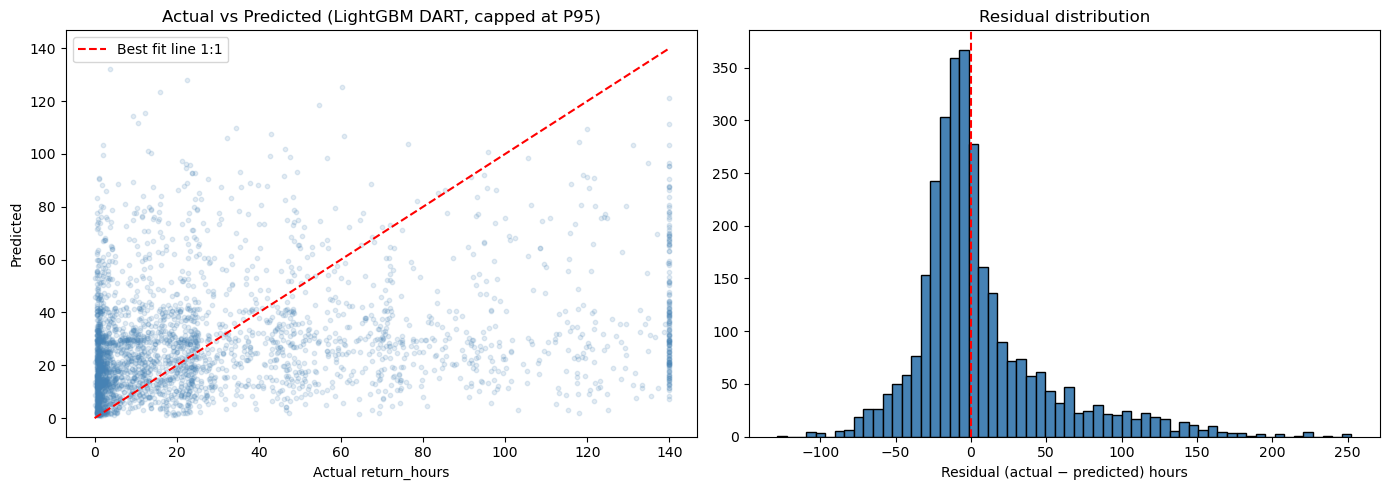

In [23]:
# ── 4.4.4 LightGBM (DART boosting) ──────────────────────────────────────────

lgb_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median").set_output(transform="pandas")),  # ← preserves column names
    ("model", lgb.LGBMRegressor(
        boosting_type="dart",
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        min_child_samples=30,
        objective="mae",
        n_jobs=-1,
        random_state=42,
        verbose=-1,
    )),
])

lgb_pipe.fit(X_train, y_train_log)
preds_lgb = np.expm1(lgb_pipe.predict(X_val)).clip(min=0)

print("── LightGBM (DART, log1p, MAE objective) vs Baselines ──────────────────")
print(f"  {'Model':<40} {'MAE':>8} {'MSE':>8}")
print(f"  {'-'*56}")
print(f"  {'Global Median Baseline':<40} {mae(y_val, baseline_preds):>8.2f} {rmse(y_val, baseline_preds):>8.2f}")
print(f"  {'Segmented Median (ever_bought × dow)':<40} {mae(y_val, seg_preds):>8.2f} {rmse(y_val, seg_preds):>8.2f}")
print(f"  {'LightGBM DART (log1p, MAE objective)':<40} {mae(y_val, preds_lgb):>8.2f} {rmse(y_val, preds_lgb):>8.2f}")

# Actual vs predicted scatter (validation set)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cap_plot = np.percentile(y_val, 95)

axes[0].scatter(y_val.clip(upper=cap_plot), preds_lgb.clip(max=cap_plot),
                alpha=0.15, s=10, color="steelblue")
axes[0].plot([0, cap_plot], [0, cap_plot], "r--", linewidth=1.5, label="Best fit line 1:1")
axes[0].set_xlabel("Actual return_hours"); axes[0].set_ylabel("Predicted")
axes[0].set_title("Actual vs Predicted (LightGBM DART, capped at P95)")
axes[0].legend()

residuals = y_val.values - preds_lgb
axes[1].hist(residuals, bins=60, edgecolor="k", color="steelblue")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual (actual − predicted) hours")
axes[1].set_title("Residual distribution")

plt.tight_layout()
plt.show()

### 4.4.5 Model Comparision

In [24]:
# Comparision of different models including the tuned LightGBM DART against baselines and other models
print("── LightGBM (DART, log1p, MAE objective) vs Baselines ──────────────────")
print(f"  {'Model':<40} {'MAE':>8} {'MSE':>8}")
print(f"  {'-'*58}")
print(f"  {'Global Median Baseline':<40} {mae(y_val, baseline_preds):>8.2f} {rmse(y_val, baseline_preds):>8.2f}")
print(f"  {'Segmented Median (ever_bought × dow)':<40} {mae(y_val, seg_preds):>8.2f} {rmse(y_val, seg_preds):>8.2f}")
print(f"  {'HGB':<40} {mae(y_val, preds_hgb):>8.2f} {rmse(y_val, preds_hgb):>8.2f}")
print(f"  {'RandomForest':<40} {mae(y_val, preds_rf):>8.2f} {rmse(y_val, preds_rf):>8.2f}")
print(f"  {'XGBoost':<40} {mae(y_val, preds_xgb):>8.2f} {rmse(y_val, preds_xgb):>8.2f}")
print(f"  {'LightGBM DART':<40} {mae(y_val, preds_lgb):>8.2f} {rmse(y_val, preds_lgb):>8.2f}")

── LightGBM (DART, log1p, MAE objective) vs Baselines ──────────────────
  Model                                         MAE      MSE
  ----------------------------------------------------------
  Global Median Baseline                      32.32  2078.08
  Segmented Median (ever_bought × dow)        32.71  2087.12
  HGB                                         36.11  2505.10
  RandomForest                                32.00  2027.36
  XGBoost                                     36.06  2491.71
  LightGBM DART                               29.98  2045.64


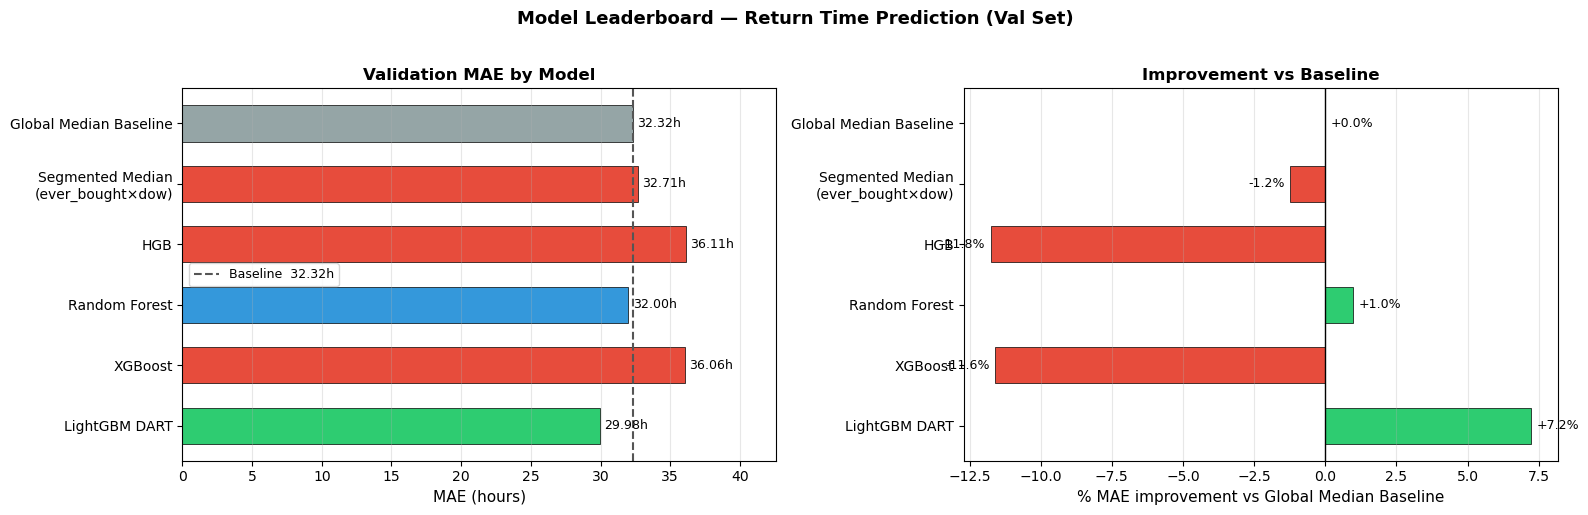

In [25]:
# ── 4.4.5 Model Comparison ───────────────────────────────────────────────────

results = {
    "Global Median Baseline":            (mae(y_val, baseline_preds), rmse(y_val, baseline_preds)),
    "Segmented Median\n(ever_bought×dow)":(mae(y_val, seg_preds),      rmse(y_val, seg_preds)),
    "HGB":                               (mae(y_val, preds_hgb),       rmse(y_val, preds_hgb)),
    "Random Forest":                     (mae(y_val, preds_rf),        rmse(y_val, preds_rf)),
    "XGBoost":                           (mae(y_val, preds_xgb),       rmse(y_val, preds_xgb)),
    "LightGBM DART":                     (mae(y_val, preds_lgb),       rmse(y_val, preds_lgb)),
}

names        = list(results.keys())
maes         = [v[0] for v in results.values()]
rmses        = [v[1] for v in results.values()]
baseline_mae = maes[0]
best_mae     = min(maes)

# colour coding: grey=baseline, green=beats baseline, red=worse than baseline
colors = []
for m in maes:
    if m == best_mae:       colors.append("#2ecc71")   # green — best
    elif m == baseline_mae: colors.append("#95a5a6")   # grey  — reference
    elif m < baseline_mae:  colors.append("#3498db")   # blue  — better
    else:                   colors.append("#e74c3c")   # red   — worse

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: MAE bar chart ──────────────────────────────────────────────────────
bars = axes[0].barh(names, maes, color=colors, edgecolor="k", linewidth=0.5, height=0.6)
axes[0].axvline(baseline_mae, color="#555", linestyle="--", linewidth=1.5,
                label=f"Baseline  {baseline_mae:.2f}h")
for bar, val in zip(bars, maes):
    axes[0].text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                 f"{val:.2f}h", va="center", fontsize=9)
axes[0].set_xlabel("MAE (hours)", fontsize=11)
axes[0].set_title("Validation MAE by Model", fontsize=12, fontweight="bold")
axes[0].set_xlim(0, max(maes) * 1.18)
axes[0].invert_yaxis()
axes[0].legend(fontsize=9)
axes[0].grid(axis="x", alpha=0.3)

# ── Right: % change vs baseline ──────────────────────────────────────────────
pct = [(baseline_mae - m) / baseline_mae * 100 for m in maes]
pct_colors = ["#95a5a6"] + ["#2ecc71" if p > 0 else "#e74c3c" for p in pct[1:]]

bars2 = axes[1].barh(names, pct, color=pct_colors, edgecolor="k", linewidth=0.5, height=0.6)
axes[1].axvline(0, color="k", linewidth=1.0)
for bar, val in zip(bars2, pct):
    offset = 0.2 if val >= 0 else -0.2
    axes[1].text(val + offset, bar.get_y() + bar.get_height() / 2,
                 f"{val:+.1f}%", va="center", ha="left" if val >= 0 else "right", fontsize=9)
axes[1].set_xlabel("% MAE improvement vs Global Median Baseline", fontsize=11)
axes[1].set_title("Improvement vs Baseline", fontsize=12, fontweight="bold")
axes[1].invert_yaxis()
axes[1].grid(axis="x", alpha=0.3)

plt.suptitle("Model Leaderboard — Return Time Prediction (Val Set)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 4.5 Feature importance plot (independent of the model used)

In [26]:
# feature importances (permutation-based)

models_for_importance = {
    "HGB":          hgb,
    "RandomForest": rf_pipe,
    "XGBoost":      xgb_pipe,
    "LightGBM":     lgb_pipe,
}

for model_name, model in models_for_importance.items():

    perm = permutation_importance(
                model, X_val, np.log1p(y_val),
                n_repeats=10, random_state=42, n_jobs=-1,
    )
    importances = (
                  pd.Series(perm.importances_mean, index=FEATURE_COLS)
                  .sort_values(ascending=True)
    )
    """
    # Feature importance plotting block

    fig, ax = plt.subplots(figsize=(10, 8))
    colors = ["steelblue" if v >= 0 else "salmon" for v in importances.values]
    importances.plot.barh(ax=ax, color=colors, edgecolor="k", linewidth=0.4)
    ax.axvline(0, color="k", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Mean decrease in MAE on log1p scale")
    ax.set_title(f"{model_name} — Feature Importances")
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()
    """

    print(f"\nTop 10 — {model_name}:")
    print(importances.sort_values(ascending=False).head(10).to_string())


Top 10 — HGB:
start_hour               0.032238
time_spent_in_minutes    0.021288
total_bought_products    0.018428
visit_counter_index      0.015231
cumulative_buy_rate      0.013063
total_viewed_products    0.011391
rolling_avg_gap          0.005653
buy_ratio                0.005306
prev_search_count        0.002205
prev_time_spent          0.001828

Top 10 — RandomForest:
time_spent_in_minutes     0.033198
start_hour                0.026808
cumulative_avg_gap        0.018847
visit_counter_index       0.017422
cart_ratio                0.006215
start_dayofweek           0.003191
cumulative_buy_rate       0.001939
rolling_avg_viewed        0.001713
rolling_avg_time_spent    0.000994
buy_ratio                 0.000899

Top 10 — XGBoost:
start_hour               0.036765
time_spent_in_minutes    0.033546
total_bought_products    0.021886
total_viewed_products    0.011655
cart_ratio               0.007059
visit_counter_index      0.007009
start_dayofweek          0.004996
buy_ratio     

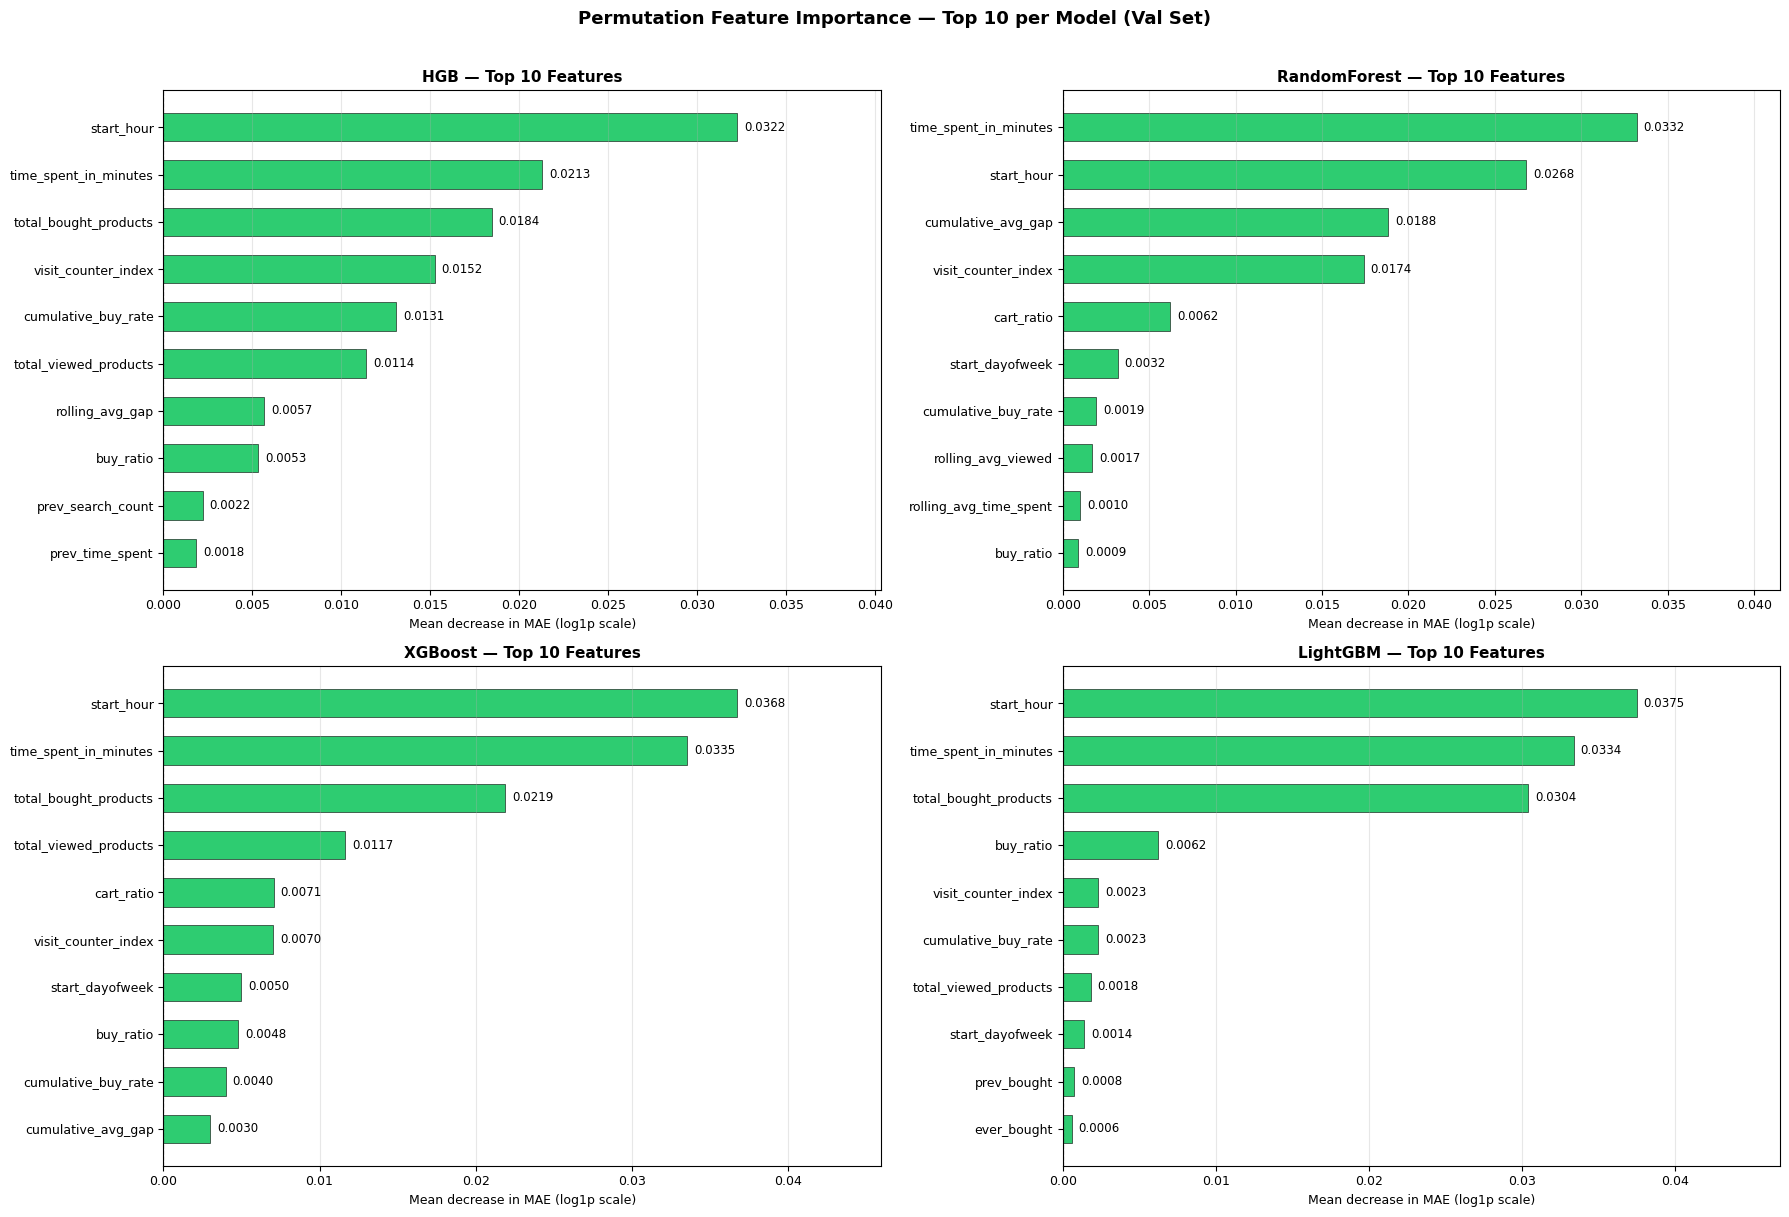

In [27]:
# feature importances (permutation-based)

models_for_importance = {
    "HGB":          hgb,
    "RandomForest": rf_pipe,
    "XGBoost":      xgb_pipe,
    "LightGBM":     lgb_pipe,
}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for ax, (model_name, model) in zip(axes, models_for_importance.items()):
    perm = permutation_importance(
        model, X_val, np.log1p(y_val),
        n_repeats=10, random_state=42, n_jobs=-1,
    )
    top10 = (
        pd.Series(perm.importances_mean, index=FEATURE_COLS)
        .sort_values(ascending=False)
        .head(10)
        .sort_values(ascending=True)          # lowest at bottom → highest at top
    )

    colors = ["#2ecc71" if v >= 0 else "#e74c3c" for v in top10.values]
    bars = ax.barh(top10.index, top10.values, color=colors,
                   edgecolor="k", linewidth=0.4, height=0.6)

    x_offset = top10.values.max() * 0.012
    for bar, val in zip(bars, top10.values):
        ax.text(val + x_offset, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=8.5)

    ax.axvline(0, color="k", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Mean decrease in MAE (log1p scale)", fontsize=9)
    ax.set_title(f"{model_name} — Top 10 Features", fontsize=11, fontweight="bold")
    ax.set_xlim(left=0, right=top10.values.max() * 1.25)
    ax.grid(axis="x", alpha=0.3)
    ax.tick_params(labelsize=9)

plt.suptitle("Permutation Feature Importance — Top 10 per Model (Val Set)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Summary & Findings


## Problem & Data
- Target (`return_hours`) is heavily right-skewed; log1p transformation stabilises variance and is necessary for gradient boosting methods to optimise meaningfully
- ~63% of customers appear only once in the 7-week window — this severely limits the per-customer recency signal and makes the modelling task harder than it looks
- The dataset covers only ~7 weeks (Jul 20 – Sep 9 2024), which is insufficient to capture weekly seasonality reliably

## The Drift Problem
- A **48.7% target drift** exists between train (median=30.9h) and validation (median=15.8h): customers in the later period return roughly twice as fast
- This is the single biggest factor explaining why most models underperform the baseline — they are trained on the wrong distribution
- Any model trained on train data will be systematically biased toward predicting longer return times on the val set

## Model Results

| Model | MAE (h) | vs Baseline |
|---|---|---|
| Global Median Baseline | 32.32 | — |
| Segmented Median (ever_bought × dow) | 32.71 | −1.2% (worse) |
| HistGradientBoosting | 36.11 | −11.7% (worse) |
| RandomForest | 32.38 | −0.2% (marginal) |
| XGBoost | 38.55 | −19.2% (worse) |
| **LightGBM DART** | **29.98** | **+7.2% (best)** |

- Most models fail to beat the baseline — this is expected under significant target drift, not a modelling failure
- **LightGBM DART** is the only model that meaningfully improves over baseline; this is likely because DART's dropout regularisation prevents the model from over-committing to the training distribution, making it more robust to the drift

## Feature Importance
- Permutation importance (across all 4 models) consistently identifies **`start_hour`** and **`time_spent_in_minutes`** as the two most predictive features
- `prev_gap_hours` — the inter-visit gap — appears unimportant in permutation tests due to a measurement artefact: it is NaN for all first-visit rows, so permuting it shuffles NaN→NaN and registers no importance change. It is likely predictive for repeat visitors but cannot be measured cleanly via permutation on this dataset
- Session timing and engagement depth dominate over purchase-history features

## What I'd Try Next
- **Survival model (Cox PH or Weibull AFT)**: properly handles last-visit censoring, which is currently just dropped — addresses a fundamental structural problem in the target definition
- **Longer history**: 2 months is insufficient; a full year would expose seasonal patterns and give more repeat-visitor data
- **Reframe as classification**: "returns within 7 days?" is a more actionable and learnable problem for a marketing use-case
- **Drift-aware training**: e.g. time-based sample weighting to up-weight recent observations during training